# **Business Case: Yulu - Hypothesis Testing**

##**Submitted By: Aravinth Baskar**

# 1.Problem Statement

Yulu is a micro-mobility service provider that offers shared electric cycles
for daily commuting.

The company has recently experienced a decline in revenue and wants to
understand the factors that affect the demand for shared electric cycles.

The main objective is to identify:

1. Which variables significantly affect the demand for electric cycles.
2. How well these variables explain the demand.

## Dependent Variable

- count: Total number of rented electric cycles.

## Independent Variables

- season
- holiday
- workingday
- weather
- temp
- atemp
- humidity
- windspeed

# 2. Data Description

The dataset contains information about electric cycle rentals along with weather and calendar-related factors.

| Column | Description |
|---|---|
| datetime | Date and time of the rental |
| season | Season: 1 = Spring, 2 = Summer, 3 = Fall, 4 = Winter |
| holiday | 1 = Holiday, 0 = Not a holiday |
| workingday | 1 = Neither weekend nor holiday, 0 = Otherwise |
| weather | 1 = Clear, 2 = Mist/Cloudy, 3 = Light rain/Snow, 4 = Heavy rain/Ice/Snow/Fog |
| temp | Temperature in Celsius |
| atemp | Feeling temperature in Celsius |
| humidity | Relative humidity |
| windspeed | Wind speed |
| casual | Number of rentals by casual users |
| registered | Number of rentals by registered users |
| count | Total number of rentals |

# 3. Importing Required Libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import levene
from scipy.stats import shapiro

# 4. Reading the Dataset

In [ ]:
!gdown 12DlUIe7eX8Nf9tOInd9Jjq5gbW9bf0rp

Downloading...
From: https://drive.google.com/uc?id=12DlUIe7eX8Nf9tOInd9Jjq5gbW9bf0rp
To: /content/yulu.csv
100% 648k/648k [00:00<00:00, 6.75MB/s]


In [ ]:
df = pd.read_csv("yulu.csv")

# 5. Non-Graphical Analysis

## 5.1 Initial Data Inspection



In [ ]:
df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


## 5.2 Shape of the Dataset



In [ ]:
df.shape

(10886, 12)

## 5.3 Dataset Information


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


## 5.4 Datatype Conversion

Some variables in the dataset represent categorical information even though they may initially be stored as an object or integer data type. Converting these variables to the category datatype makes their nature explicit and can also improve memory efficiency.

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

df[['season', 'holiday', 'workingday', 'weather']] = df[['season', 'holiday', 'workingday', 'weather']].astype('category')

## 5.5 Unique Values and Value Counts



In [ ]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [ ]:
categorical_columns = df.select_dtypes(include='category').columns
for i in categorical_columns:
    print(df[i].value_counts())
    print("---" * 10)

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
------------------------------
holiday
0    10575
1      311
Name: count, dtype: int64
------------------------------
workingday
1    7412
0    3474
Name: count, dtype: int64
------------------------------
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
------------------------------


## 5.6 Missing Values



In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


## 5.7 Duplicate Records



In [ ]:
df.duplicated().sum()

np.int64(0)

## 5.8 Statistical Summary

In [ ]:
df.select_dtypes(include="number").describe()

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


## 5.9 Insights from Non-Graphical Analysis

- The dataset contains 10886 rows and 12 columns, representing hourly data.

- The dataset contains no missing values, so no missing-value treatment is required.

- There are no duplicate records in the dataset.

- The dataset contains both numerical and categorical attributes. Categorical attributes were converted to the category datatype where appropriate.

- The average rental count is 191.57, while the median is 145, indicating a right-skewed distribution.

- Registered users have a higher average rental count (155.55) compared to casual users (36.02).

- The observations are fairly balanced across seasons, with each season having around 2,700 records.

- Most observations are from non-holidays (10,575) compared to holidays (311).

- Most observations are from working days (7,412) compared to non-working days (3,474).

- Clear weather conditions (weather category 1) have the highest number of observations (7,192), while weather category 4 has only one observation.




# 6. Outlier Analysis

## 6.1 Outlier Detection

Boxplots are used to visually identify potential outliers in the numerical variables.

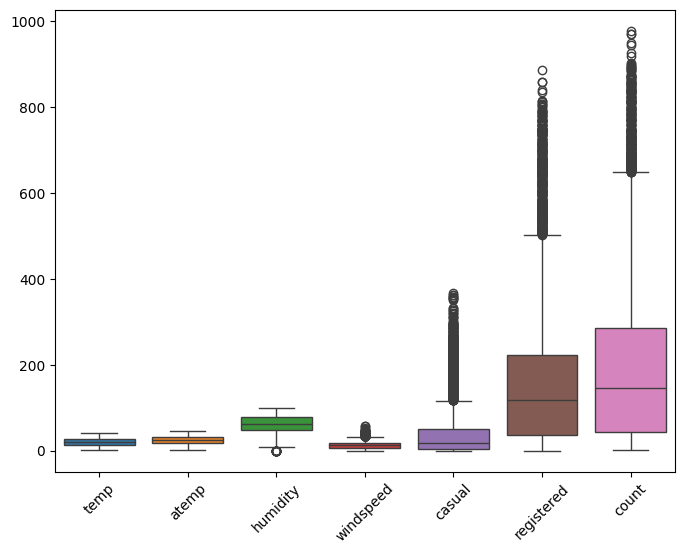

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.show()

## 6.2 Outlier Percentage

In [ ]:
numerical_columns = df.select_dtypes(include="number").columns
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    percentage = len(outliers) / len(df) * 100

    print(f"{col}: {percentage:.2f}%")

temp: 0.00%
atemp: 0.00%
humidity: 0.20%
windspeed: 2.09%
casual: 6.88%
registered: 3.89%
count: 2.76%


## 6.3 Outlier Treatment

The identified outliers are retained as they may represent genuine variations in rental demand rather than data-entry errors. Removing them could result in the loss of meaningful information.

# 7. Graphical Analysis

## 7.1 Univariate Analysis

### 7.1.1 Distribution of Count

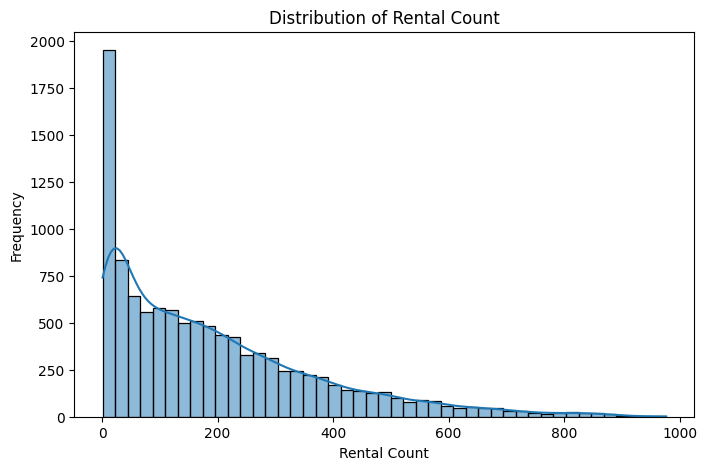

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['count'], kde=True)
plt.title('Distribution of Rental Count')
plt.xlabel('Rental Count')
plt.ylabel('Frequency')
plt.show()

###Observation

- The rental count distribution is right-skewed.
- Most rental counts are concentrated at lower values.
- A long right tail indicates that a smaller number of observations have much higher rental counts.

###7.1.2 Distribution of Continuous Variables

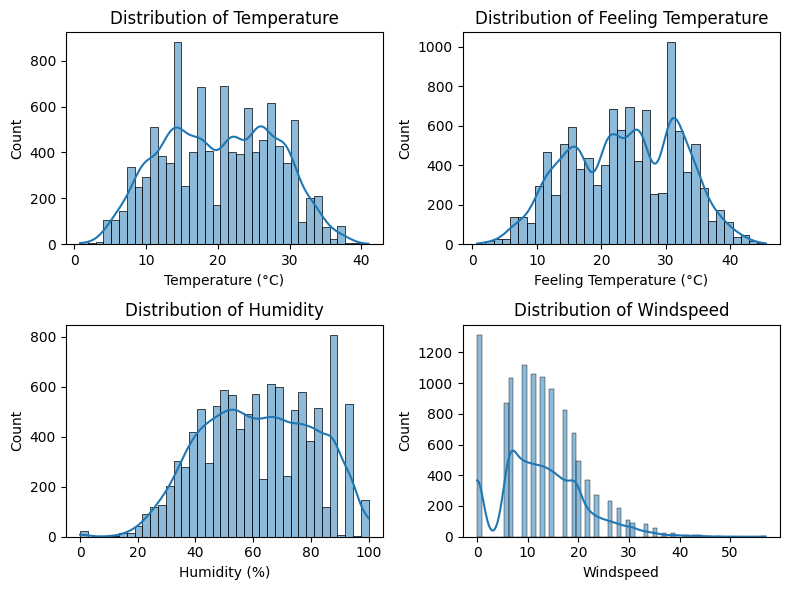

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.histplot(df['temp'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Temperature')
axes[0, 0].set_xlabel('Temperature (°C)')

sns.histplot(df['atemp'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Feeling Temperature')
axes[0, 1].set_xlabel('Feeling Temperature (°C)')

sns.histplot(df['humidity'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Humidity')
axes[1, 0].set_xlabel('Humidity (%)')

sns.histplot(df['windspeed'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Windspeed')
axes[1, 1].set_xlabel('Windspeed')

plt.tight_layout()
plt.show()

###Observation

- Temperature is fairly evenly spread between roughly 5°C and 35°C, with no single dominant peak.
- Feeling temperature (atemp) follows a similar broad spread to temp, with a slightly denser concentration around 30°C.
- Humidity is left-skewed: values are concentrated in the 40–90% range.
- Windspeed is right-skewed with a sharp spike at 0 — a large number of hours have little to no wind — followed by a peak around 7–15, and a long tail extending toward 40–55 representing occasional high-wind periods.

### 7.1.3 Categorical Variable Distributions

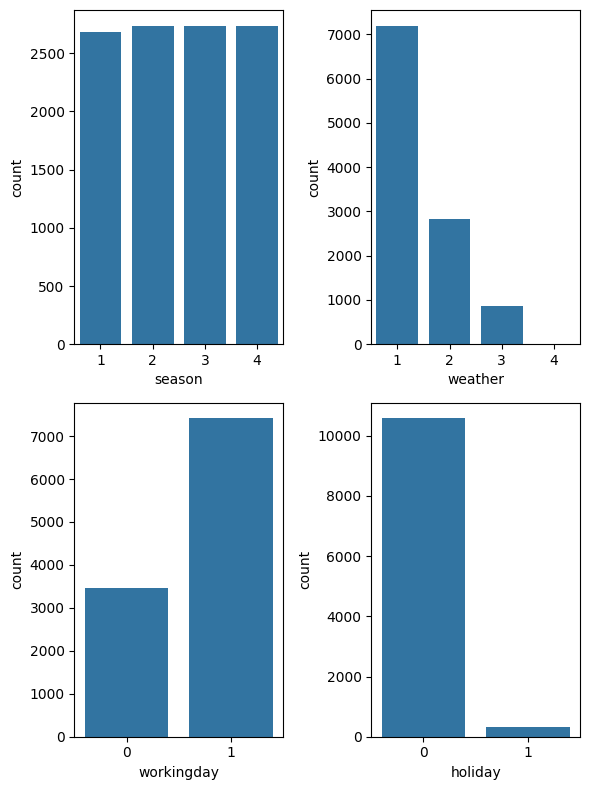

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(6, 8))

sns.countplot(data=df, x='season', ax=axes[0, 0])
sns.countplot(data=df, x='weather', ax=axes[0, 1])
sns.countplot(data=df, x='workingday', ax=axes[1, 0])
sns.countplot(data=df, x='holiday', ax=axes[1, 1])

plt.tight_layout()
plt.show()

#### Observation

- The observations are fairly balanced across all four seasons.
- Clear weather (1) has the highest number of observations, followed by weather 2 and 3.
- Heavy rain (Weather 4) has almost no observations, making it highly underrepresented.
- Working days have considerably more observations than non-working days.
- Non-holidays greatly outnumber holidays.

## 7.2 Bivariate Analysis

### 7.2.1 Workingday vs Count

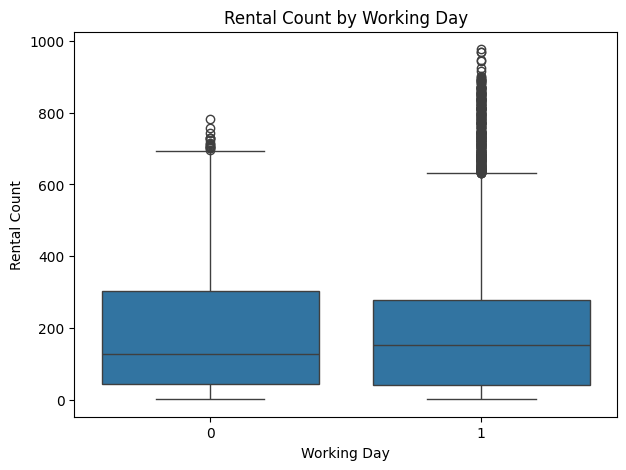

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='workingday', y='count')
plt.title('Rental Count by Working Day')
plt.xlabel('Working Day')
plt.ylabel('Rental Count')
plt.show()

#### Observation

- The median rental count appears slightly higher on working days than on non-working days.
- Both groups show considerable variation in rental counts.
- Several high-value observations are visible as potential outliers, particularly for working days.
- The boxplots suggest that working day may have an association with rental count, which will be formally tested using a 2-sample t-test.

### 7.2.2 Season vs Count

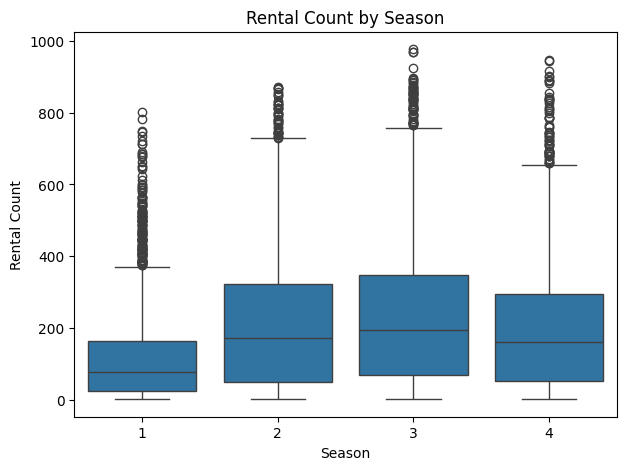

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='season', y='count')
plt.title('Rental Count by Season')
plt.xlabel('Season')
plt.ylabel('Rental Count')
plt.show()

#### Observation

- Rental counts vary across seasons, with season 3 (Fall) showing the highest median rental count.
- Season 1 has the lowest median rental count.
- Seasons 2, 3, and 4 show higher rental counts compared to season 1.
- All seasons contain several high-value observations.
- The differences across seasons suggest that season may be associated with rental demand, which will be formally tested using a one-way ANOVA.

### 7.2.3 Weather vs Count

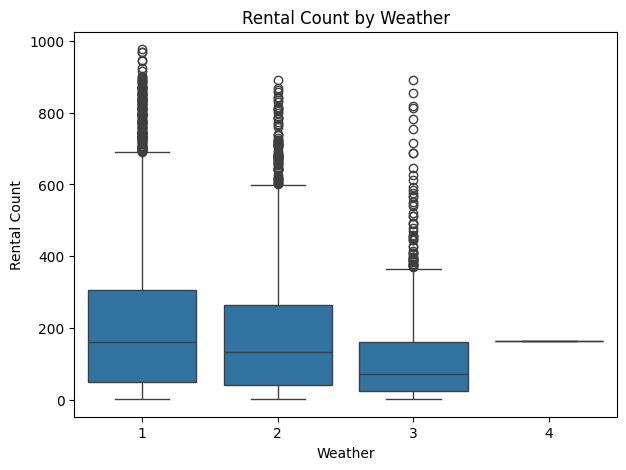

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='weather', y='count')
plt.title('Rental Count by Weather')
plt.xlabel('Weather')
plt.ylabel('Rental Count')
plt.show()

#### Observation

- Rental counts appear to vary across weather conditions.
- Clear weather (1) has the highest median rental count, while weather 3 has a lower median.
- Weather 4 has only one observation, so its distribution cannot be meaningfully compared.
- The variation across weather conditions suggests that weather may be associated with rental demand, which will be formally tested using a one-way ANOVA.

### 7.2.4 Weather vs Season

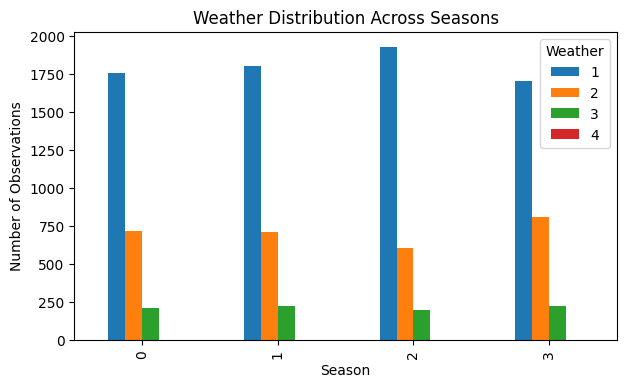

In [ ]:
weather_season = pd.crosstab(df['season'], df['weather']).reset_index()

weather_season.plot(kind = "bar", figsize=(7,4) )

plt.title('Weather Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Observations')
plt.legend(title='Weather')
plt.show()

#### Observation

- Weather 1 (clear conditions) is the most frequent weather category across all seasons.
- Weather 4 has no visible observations in the plot, indicating it is extremely rare in the dataset.
- The distribution of weather categories varies across seasons, suggesting a possible association between weather and season.
- This relationship will be formally tested using the Chi-square test of independence.

### 7.2.5 Correlation Heatmap

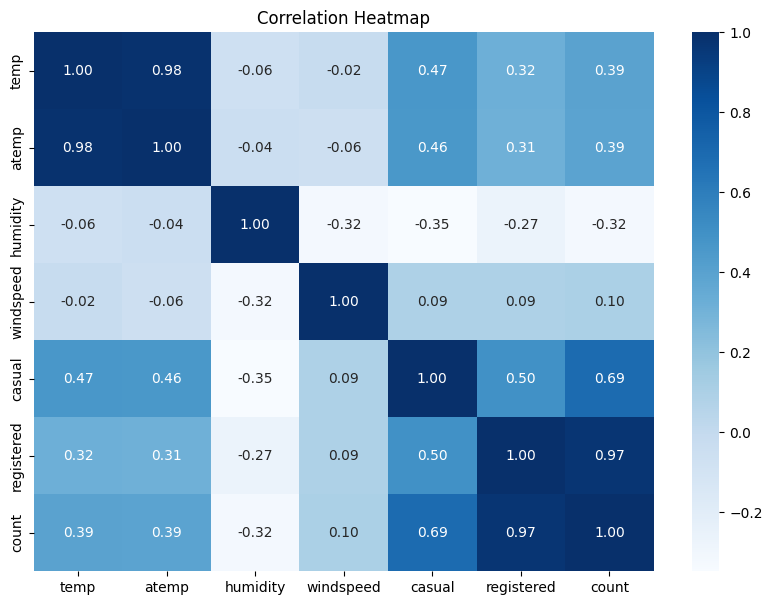

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

### Observation

- temp and atemp have a very strong positive correlation (0.98).
- casual and registered both contribute to count, since count = casual + registered. So they both have strong correlation with count.
- humidity has a moderate negative correlation with count (-0.32).
- windspeed has a very weak correlation with count (0.10).


# 8. Hypothesis Testing

## 8.1 Two-Sample T-Test: Workingday vs Count

### 8.1.1 Hypothesis Formulation

H₀: The mean rental count is the same for working days and non-working days.

H₁: The mean rental count is different for working days and non-working days.

The significance level is set at α = 0.05.

### 8.1.2 Normality Check

The Shapiro-Wilk test is used to check whether the rental counts are normally distributed within each group.

In [ ]:
# Split count by working day status to compare distributions
workingday = df[df['workingday'] == 1]['count']
non_workingday = df[df['workingday'] == 0]['count']

print("Working Day:", shapiro(workingday))
print("Non-Working Day:", shapiro(non_workingday))

Working Day: ShapiroResult(statistic=np.float64(0.8702545795617624), pvalue=np.float64(2.2521124830019574e-61))
Non-Working Day: ShapiroResult(statistic=np.float64(0.885211755076074), pvalue=np.float64(4.4728547627911074e-45))


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7412.
  res = hypotest_fun_out(*samples, **kwds)


### Q-Q Plot

Since the sample sizes are large, Q-Q plots is used for visual confirmation of normal distribution.

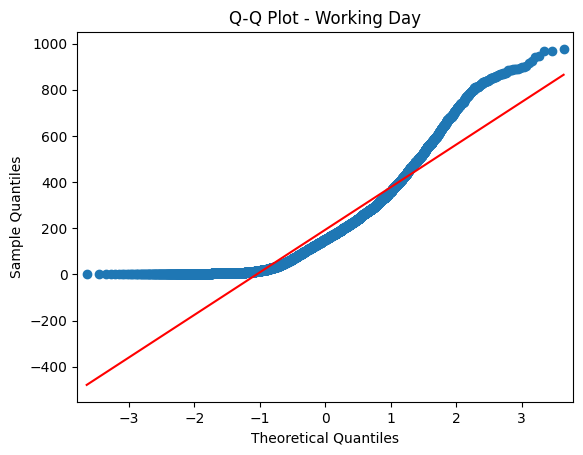

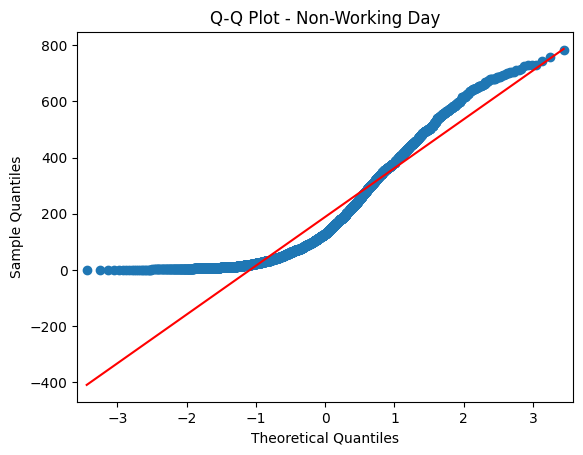

In [ ]:
from statsmodels.graphics.gofplots import qqplot

qqplot(workingday, line='s')
plt.title("Q-Q Plot - Working Day")
plt.show()

qqplot(non_workingday, line='s')
plt.title("Q-Q Plot - Non-Working Day")
plt.show()


- The Shapiro-Wilk test rejected the null hypothesis, indicating that the data is not normally distributed in either group.
- The Q-Q plots for both working days and non-working days show noticeable deviation from the reference line.
- This indicates that the rental count data is not normally distributed in either group.
- The normality assumption is therefore violated.

### 8.1.3 Equality of Variance Check

In [ ]:
levene_result = levene(workingday, non_workingday)

print(levene_result)

LeveneResult(statistic=np.float64(0.004972848886504472), pvalue=np.float64(0.9437823280916695))


- The Levene's test p-value is 0.9438, which is greater than 0.05.
- Therefore, we fail to reject the null hypothesis.
- There is no significant difference between the variances of the two groups.
- The equal-variance assumption is satisfied.

### 8.1.4 Two-Sample T-Test

In [ ]:
t_stat, p_value = ttest_ind(workingday, non_workingday)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.2096277376026694
p-value: 0.22644804226361348


- The p-value is 0.2264, which is greater than the significance level of 0.05.
- Therefore, we fail to reject the null hypothesis.
- There is no statistically significant difference in the mean rental count between working days and non-working days.
- Based on the sample data, working day status does not have a statistically significant effect on the number of rentals.

## 8.2 One-Way ANOVA: Season vs Count
We test whether the mean rental count differs across the four seasons.



### 8.2.1 Hypothesis Formulation
H₀: The mean rental count is the same across all seasons.

H₁: At least one season has a different mean rental count.

The significance level is set at α = 0.05.

###8.2.2 Normality Check
The Shapiro-Wilk test is used to check whether the rental counts are normally distributed within each season.

In [ ]:
# Split count by season to compare distributions across the 4 groups
season1 = df[df['season'] == 1]['count']
season2 = df[df['season'] == 2]['count']
season3 = df[df['season'] == 3]['count']
season4 = df[df['season'] == 4]['count']

print("Season 1:", shapiro(season1))
print("Season 2:", shapiro(season2))
print("Season 3:", shapiro(season3))
print("Season 4:", shapiro(season4))

Season 1: ShapiroResult(statistic=np.float64(0.8087378401253588), pvalue=np.float64(8.749584618867662e-49))
Season 2: ShapiroResult(statistic=np.float64(0.9004818080893252), pvalue=np.float64(6.039374406270491e-39))
Season 3: ShapiroResult(statistic=np.float64(0.9148166372899196), pvalue=np.float64(1.043680518918597e-36))
Season 4: ShapiroResult(statistic=np.float64(0.8954637482095505), pvalue=np.float64(1.1299244409282836e-39))


### Q-Q Plot

Since the sample sizes are large, Q-Q plots is used for visual confirmation of normal distribution.

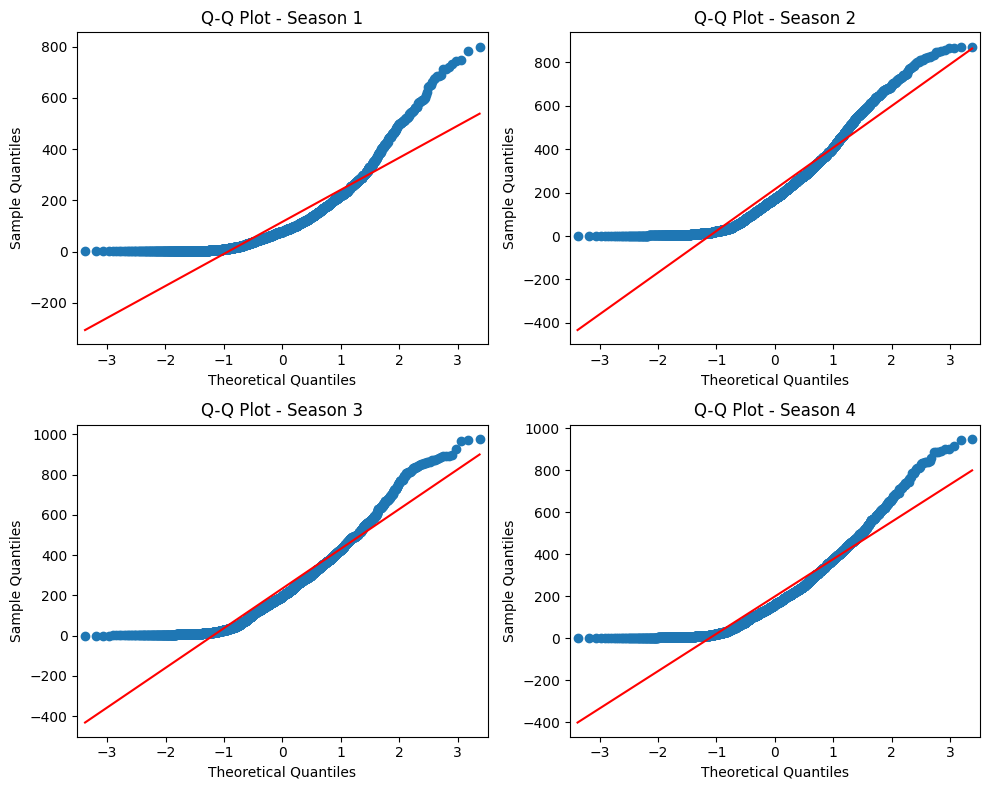

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

qqplot(season1, line='s', ax=axes[0, 0])
axes[0, 0].set_title("Q-Q Plot - Season 1")

qqplot(season2, line='s', ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot - Season 2")

qqplot(season3, line='s', ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot - Season 3")

qqplot(season4, line='s', ax=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot - Season 4")

plt.tight_layout()
plt.show()

- The Shapiro-Wilk test rejected the null hypothesis for all four seasons, indicating that the rental count data is not normally distributed in any of the four seasons.
- The Q-Q plots for all four seasons show noticeable deviation from the reference line.
- This indicates that the rental count data is not normally distributed within any of the seasons.
- Therefore, the normality assumption is violated.

### 8.2.3 Equality of Variance Check

For ANOVA, we use Levene's test to check whether the variances are equal across the four season groups.

In [ ]:
levene_result = levene(season1, season2, season3, season4)
print(levene_result)

LeveneResult(statistic=np.float64(187.7706624026276), pvalue=np.float64(1.0147116860043298e-118))


- The Levene's test p-value is extremely small (p < 0.05).
- Therefore, we reject the null hypothesis.
- There is a significant difference between the variances of the four season groups.
- The equal-variance assumption is therefore violated.

### 8.2.4 One-Way ANOVA
Now perform the one-way ANOVA to test whether the mean rental count differs across the four seasons.

In [ ]:
f_stat, p_value = f_oneway(season1, season2, season3, season4)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 236.94671081032098
p-value: 6.164843386499654e-149


- The p-value is extremely small (p < 0.05).
- Therefore, we reject the null hypothesis.
- There is a statistically significant difference in mean rental count across the four seasons.

###8.2.5 Kruskal-Wallis Test — Additional Analysis
Because the normality and equal-variance assumptions were violated, the Kruskal-Wallis test can be used as a non-parametric alternative to one-way ANOVA.

In [ ]:
from scipy.stats import kruskal

stat, p_value = kruskal(season1, season2, season3, season4)

print("statistic:", stat)
print("p-value:", p_value)

statistic: 699.6668548181988
p-value: 2.479008372608633e-151


- The p-value is extremely small (p < 0.05).
- Therefore, we reject the null hypothesis.
- There is a statistically significant difference in rental counts across the four seasons.
- The Kruskal-Wallis test supports the conclusion obtained from the one-way ANOVA.

## 8.3 One-Way ANOVA: Weather vs Count

### 8.3.1 Hypothesis Formulation

H₀: The mean rental count is the same across all weather conditions.

H₁: At least one weather condition has a different mean rental count.

The significance level is set at α = 0.05.

### 8.3.2 Normality Check

The Shapiro-Wilk test is used to check whether the rental counts are normally distributed within each weather condition.

In [ ]:
# Split count by weather to compare distributions across the 4 groups
weather1 = df[df['weather'] == 1]['count']
weather2 = df[df['weather'] == 2]['count']
weather3 = df[df['weather'] == 3]['count']
weather4 = df[df['weather'] == 4]['count']

print("Weather 1:", shapiro(weather1))
print("Weather 2:", shapiro(weather2))
print("Weather 3:", shapiro(weather3))
print("Weather 4:", shapiro(weather4))

Weather 1: ShapiroResult(statistic=np.float64(0.8909259459740138), pvalue=np.float64(1.5964921477006555e-57))
Weather 2: ShapiroResult(statistic=np.float64(0.8767694973495206), pvalue=np.float64(9.777839106111785e-43))
Weather 3: ShapiroResult(statistic=np.float64(0.7674327906035717), pvalue=np.float64(3.875893017396149e-33))
Weather 4: ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7192.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipykernel_2244/520654679.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("Weather 4:", shapiro(weather4))


### Q-Q Plot

Since the sample sizes are large, Q-Q plots is used for visual confirmation of normal distribution.

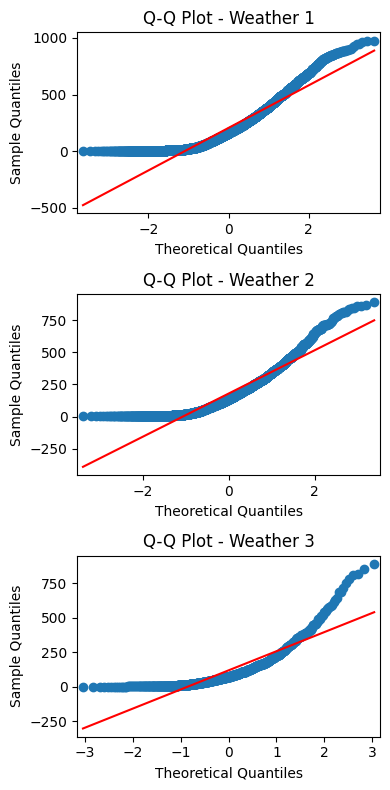

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(4,8))

qqplot(weather1, line='s', ax=axes[0])
axes[0].set_title("Q-Q Plot - Weather 1")

qqplot(weather2, line='s', ax=axes[1])
axes[1].set_title("Q-Q Plot - Weather 2")

qqplot(weather3, line='s', ax=axes[2])
axes[2].set_title("Q-Q Plot - Weather 3")

plt.tight_layout()
plt.show()

- The Shapiro-Wilk test rejected the null hypothesis for Weather 1, Weather 2, and Weather 3, indicating that the rental count data is not normally distributed within these weather conditions.
- The Q-Q plots for Weather 1, Weather 2, and Weather 3 show noticeable deviation from the reference line.
- Weather 4 contains only one observation, so the Shapiro-Wilk test and Q-Q plot cannot be meaningfully performed for this group.
- Therefore, the normality assumption is violated for the weather groups that can be tested.

### 8.3.3 Equality of Variance Check

We use Levene's test across all four weather groups.

In [ ]:
levene_result = levene(weather1, weather2, weather3, weather4)
print(levene_result)

LeveneResult(statistic=np.float64(54.85106195954556), pvalue=np.float64(3.504937946833238e-35))


- The Levene's test p-value is extremely small (p < 0.05).
- Therefore, we reject the null hypothesis.
- There is a significant difference between the variances of the four weather groups.
- The equal-variance assumption is therefore violated.

###8.3.4 One-Way ANOVA

In [ ]:
f_stat, p_value = f_oneway(weather1, weather2, weather3, weather4)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 65.53024112793265
p-value: 5.482069475935669e-42


### Additional Check: Excluding Weather 4

- Weather 4 contains only one observation, so an additional ANOVA was performed using only Weather 1, Weather 2, and Weather 3.


In [ ]:
# Excluding Weather 4 (n=1) since it can distort ANOVA results
f_stat, p_value = f_oneway(weather1, weather2, weather3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 98.28356881946705
p-value: 4.976448509904196e-43


- The p-value remains extremely small (p < 0.05) in both cases, so we reject null hypothesis.
- Therefore, the significant difference in rental count across weather conditions remains even after excluding Weather 4.
- The rental demand differs significantly across weather conditions.
- Therefore, weather has a statistically significant association with rental demand.

### 8.3.5 Kruskal-Wallis Test — Additional Analysis
Since the normality and equal-variance assumptions were violated, we can also perform the Kruskal-Wallis test as a non-parametric alternative.

In [ ]:
stat, p_value = kruskal(weather1, weather2, weather3, weather4)
print("statistic:", stat)
print("p-value:", p_value)

statistic: 205.00216514479087
p-value: 3.501611300708679e-44


- The p-value is extremely small (p < 0.05).
- Therefore, we reject the null hypothesis.
- There is a statistically significant difference in rental counts across the weather conditions.
- The Kruskal-Wallis test supports the conclusion obtained from the one-way ANOVA.

## 8.4 Chi-Square Test: Weather vs Season
This test checks whether weather conditions and seasons are independent of each other.

###8.4.1 Hypothesis Formulation

H₀: Weather conditions and seasons are independent of each other.

H₁: Weather conditions and seasons are dependent on each other.

The significance level is set at α = 0.05.

### 8.4.2 Contingency Table

A contingency table is created to show the frequency distribution of weather conditions across different seasons.

In [ ]:
weather_season = pd.crosstab(df['season'], df['weather'])

weather_season

weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


### 8.4.3 Chi-Square Contingency

The expected frequencies are calculated to check whether the assumptions of the Chi-square test are satisfied.

In [ ]:
chi2_stat, p_value, dof, expected = chi2_contingency(weather_season)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected Frequencies:")
print(expected)

Chi-square statistic: 49.158655596893624
p-value: 1.549925073686492e-07
Degrees of freedom: 9
Expected Frequencies:
[[1.77454639e+03 6.99258130e+02 2.11948742e+02 2.46738931e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80625831e+03 7.11754180e+02 2.15736359e+02 2.51148264e-01]]


- The expected frequencies for Weather 4 are approximately 0.25 across all four seasons, which is below the recommended minimum of 5.
- Therefore, the expected-frequency assumption for the Chi-square test is violated.
- The Weather 4 category is highly underrepresented, with only one observed record.
- Although the Chi-square test gives a p-value of approximately 1.55 × 10⁻⁷, the result should be interpreted with caution because the expected-frequency assumption is not satisfied.

### Additional Check: Excluding Weather 4

Since Weather 4 contains only one observation, an additional Chi-square test is performed using only Weather 1, Weather 2, and Weather 3 to assess the relationship between weather and season without the highly underrepresented category.

In [ ]:
weather_season_3 = pd.crosstab(
    df[df['weather'] != 4]['season'],
    df[df['weather'] != 4]['weather']
)

print(weather_season_3)
print("------"*9)

chi2_stat, p_value, dof, expected = chi2_contingency(weather_season_3)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected Frequencies:")
print(expected)

weather     1    2    3
season                 
1        1759  715  211
2        1801  708  224
3        1930  604  199
4        1702  807  225
------------------------------------------------------
Chi-square statistic: 46.10145731073249
p-value: 2.8260014509929343e-08
Degrees of freedom: 6
Expected Frequencies:
[[1774.04869086  699.06201194  211.8892972 ]
 [1805.76352779  711.55920992  215.67726229]
 [1805.76352779  711.55920992  215.67726229]
 [1806.42425356  711.81956821  215.75617823]]



- After excluding Weather 4, all expected frequencies are greater than 5, so the expected-frequency assumption for the Chi-square test is satisfied.
- The p-value is 2.83 × 10⁻⁸, which is less than 0.05. Therefore, we reject the null hypothesis.
- There is a statistically significant association between weather conditions and seasons, indicating that weather conditions and seasons are statistically dependent on each other.
- The relationship remains significant even after excluding Weather 4, indicating that the result is not driven solely by the single Weather 4 observation.

## 8.5 Summary of Hypothesis Testing

| Test | Result | Conclusion |
|---|---|---|
| Two-Sample T-Test: Workingday vs Count | p > 0.05 | No statistically significant difference in mean rental count |
| ANOVA: Season vs Count | p < 0.05 | Rental demand differs significantly across seasons |
| ANOVA: Weather vs Count | p < 0.05 | Rental demand differs significantly across weather conditions |
| Chi-Square: Weather vs Season | p < 0.05 | Weather conditions and seasons are statistically associated |

# 9. Business Insights and Conclusion

## 9.1 Rental Demand by Season and Weather



In [ ]:
season_means = df.groupby('season', observed=True)['count'].mean()
weather_means = df.groupby('weather', observed=True)['count'].mean()

print("Mean Rental Count by Season:")
print(season_means)

print("\nMean Rental Count by Weather:")
print(weather_means)

Mean Rental Count by Season:
season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: count, dtype: float64

Mean Rental Count by Weather:
weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64


### Average Rental Count by Season

- Spring season has the lowest average rental count of 116.34.
- Summer season has an average rental count of 215.25.
- Fall season has the highest average rental count of 234.42.
- Winter season has an average rental count of 198.99.
- This shows that rental demand is considerably higher in Seasons Summer, Fall and Winter compared to Spring.



### Average Rental Count by Weather

- Clear weather has the highest average rental count of 205.24.
- Mist/Cloudy weather has an average rental count of 178.96.
- Light rain/snow weather has a lower average rental count of 118.85.
- Heavy rain/fog has an average rental count of 164.00, but this category contains only one observation and should therefore be interpreted with caution.
- The average rental count decreases substantially under poorer weather condition.

## 9.2 Conclusion

This analysis set out to identify which factors significantly affect the demand for Yulu's shared electric cycles, and how well
those factors explain rental demand.

Key findings:
- Season and weather conditions are significantly associated with rental demand (ANOVA, p < 0.05 for both), confirmed by the non-parametric Kruskal-Wallis test as well.
- Working day status does not show a statistically significant difference in rental demand (2-sample t-test, p = 0.226). Demand does not meaningfully differ between working and non-working days.
- Weather and season are not independent of each other (Chi-square test, p < 0.05) — certain weather conditions are more likely in certain seasons, which should be accounted for when analyzing either factor in isolation.
- Rental demand is highest in Fall and lowest in Spring, and highest under clear weather, dropping sharply as conditions worsen.

**Answer to the business question:** Season and weather are the significant drivers of demand identified in this analysis,
while calendar-based factors like working day status are not.
Yulu's recent revenue dip is more likely explained by seasonal
and weather patterns (or shifts in them) than by changes in weekday/weekend commuting behavior.

##9.3 Recommendations

- **Counter seasonal dips with targeted promotions:** Since Spring shows the lowest average rentals (116 vs. 234 in Fall), Yulu could introduce seasonal discounts, ride credits or bundled subscription offers during Spring months to smooth out revenue troughs.

- **Build weather-responsive incentives:** Rentals drop substantially in Light Rain/Snow conditions (avg. 119) compared to Clear weather (avg. 205). Since weather and season are statistically linked, Yulu could pilot weather-triggered incentives to retain ridership on poor-weather days rather than losing that demand entirely.

- **Don't over-index marketing on weekday commuters:** Because working day status showed no significant effect on demand, marketing spend aimed narrowly at weekday office commuters may not move the needle. Demand appears driven more by environmental conditions than by calendar type, so campaigns should be planned around season/weather forecasts rather than the work week.

- **Expand fleet/zone availability ahead of high-demand seasons:** Given Fall and Summer show meaningfully higher demand, proactively increasing cycle availability and zone density before these seasons could help Yulu capture demand, it may currently be leaving on the table due to under-supply.

